<a href="https://colab.research.google.com/github/bhupendra17s/ML-learner/blob/main/practice1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from google.colab import files
uploaded = files.upload()
print (uploaded)

Saving house_prices_practice.csv to house_prices_practice (1).csv
{'house_prices_practice (1).csv': b'Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice\n1,7,1560,0,1658,1969,2,1,8059,177106\n2,4,2827,2,1319,2012,3,4,13530,301044\n3,8,3920,0,841,2010,1,4,9010,360609\n4,5,3044,0,1058,1998,0,4,13207,240556\n5,7,801,1,2428,2020,0,1,9117,193656\n6,10,680,1,2480,1950,2,1,13081,213952\n7,3,1106,2,1096,1962,1,4,11153,145539\n8,7,3670,1,437,2000,2,5,4989,350830\n9,8,1199,2,1653,2005,1,5,14040,275955\n10,5,1492,1,2175,2011,1,2,11218,211664\n11,4,1639,0,368,1981,1,3,8228,131861\n12,8,690,2,2400,1979,0,5,14057,209288\n13,8,2800,2,1773,1978,3,1,8471,343023\n14,3,1480,0,504,1998,2,5,4863,156829\n15,6,3475,2,2473,1994,3,2,12693,361922\n16,5,2506,2,342,1979,2,2,12139,251312\n17,2,1684,1,2206,1965,1,3,3177,186675\n18,8,3827,2,2458,1989,0,5,6760,397482\n19,6,3894,3,1060,1968,3,1,2011,352990\n20,2,627,0,2442,1967,0,1,7252,89957\n21,5,2565,1,2294,1950,2,4,63

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [10]:
df= pd.read_csv("house_prices_practice.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB
None


In [11]:
print (df.head(10))

   Id  OverallQual  GrLivArea  GarageCars  TotalBsmtSF  YearBuilt  FullBath  \
0   1            7       1560           0         1658       1969         2   
1   2            4       2827           2         1319       2012         3   
2   3            8       3920           0          841       2010         1   
3   4            5       3044           0         1058       1998         0   
4   5            7        801           1         2428       2020         0   
5   6           10        680           1         2480       1950         2   
6   7            3       1106           2         1096       1962         1   
7   8            7       3670           1          437       2000         2   
8   9            8       1199           2         1653       2005         1   
9  10            5       1492           1         2175       2011         1   

   BedroomAbvGr  LotArea  SalePrice  
0             1     8059     177106  
1             4    13530     301044  
2             4 

In [12]:
X = df[['LotArea']]
y= df['SalePrice']

X_test, X_train, y_test, y_train = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2}")

R2 Score: 0.00012295285371910492


In [14]:
comparison = pd.DataFrame({'Actual Prices': y_test, 'Predicted Prices': y_pred})
print(comparison.head(10))

     Actual Prices  Predicted Prices
232          92706     245004.367631
59          220562     260249.843268
6           145539     248783.420694
185         312483     247992.632931
173         153184     259486.935842
30          376248     246945.852974
22          327036     246171.539956
256         358541     259952.030569
56           99107     247857.033106
186         176871     249917.643529


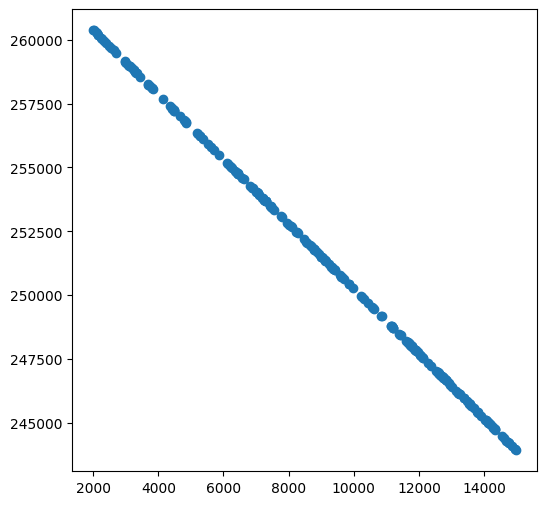

In [18]:
plt.figure(figsize=(6,6))
plt.scatter(X_test, y_pred)

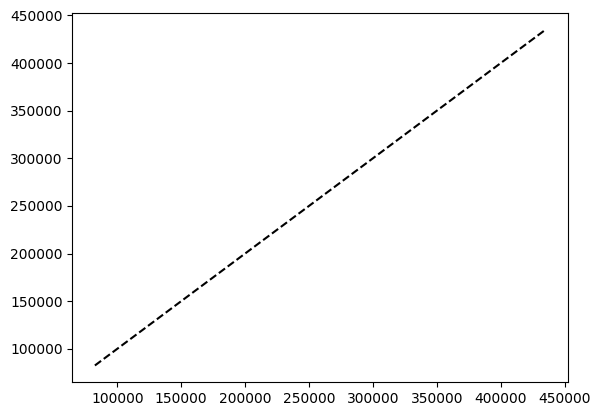

In [19]:
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--'
    )

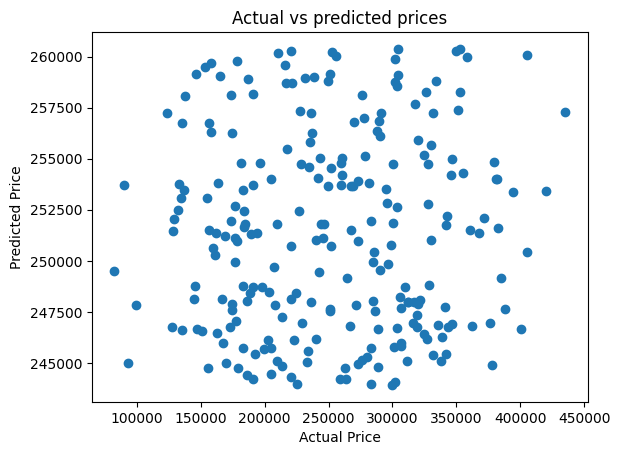

In [23]:
y_pred = model.predict(X_test)
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs predicted prices')
plt.show()